In [154]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [155]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [156]:

len(df)

10000

In [157]:
df.info() #gives info about the data frame i think mainly for seeing the data type and missing values

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [158]:
df.shape# 1000 rows and 12 columns

(10000, 12)

In [159]:
df.describe() # only works for numerical values


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [160]:
#checking the number of churned customers or let's say if the data is imbalanced or balanced
print(len(df[df['churn']== 0]))
len(df[df['churn']== 1])

7963


2037

##Data is highly imbalanced so we will use upsampling##


In [161]:
df['churn'].value_counts() #same logic as the above 

churn
0    7963
1    2037
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='Count'>

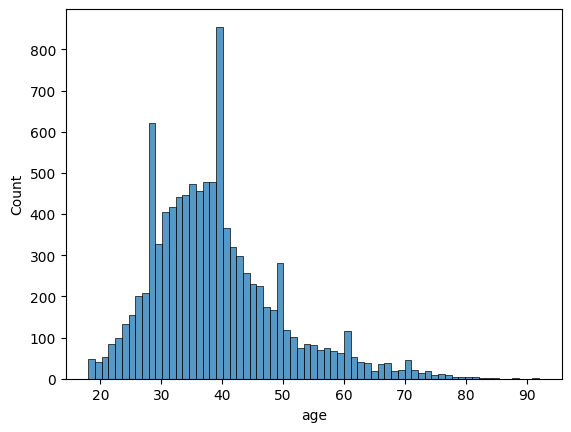

In [162]:
sns.histplot(df['age'])# checking distribution right


<Axes: xlabel='country', ylabel='count'>

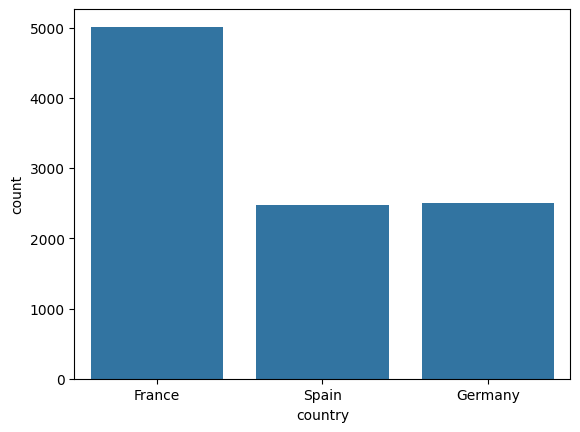

In [163]:
sns.countplot(x = df['country'])

**Can see most people are from france**

In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [165]:
# customer_id has no relation with target variable churn so let's remove it
temp = df
df = df.drop('customer_id', axis=1)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [166]:
temp.head() #checking if customer_id on temp remains or not

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: xlabel='credit_score', ylabel='Count'>

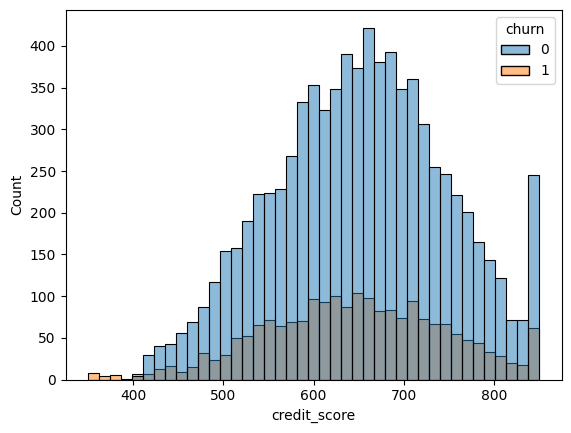

In [167]:
#churn vs credit_score
sns.histplot(data=df, x = 'credit_score', hue='churn')

<function matplotlib.pyplot.show(close=None, block=None)>

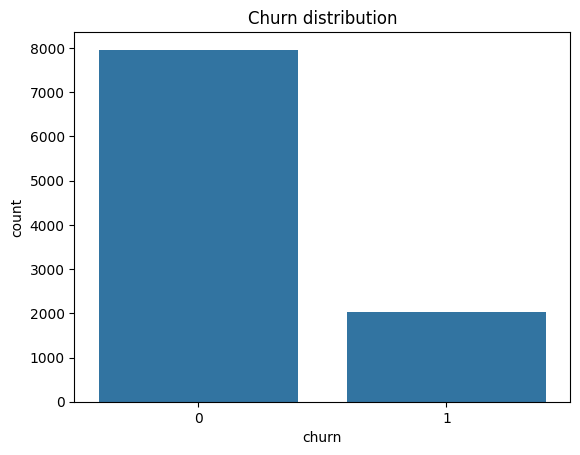

In [168]:
sns.countplot(x='churn', data=df)
plt.title('Churn distribution')
plt.show
#seeing same churn distribution but in a different way to understand


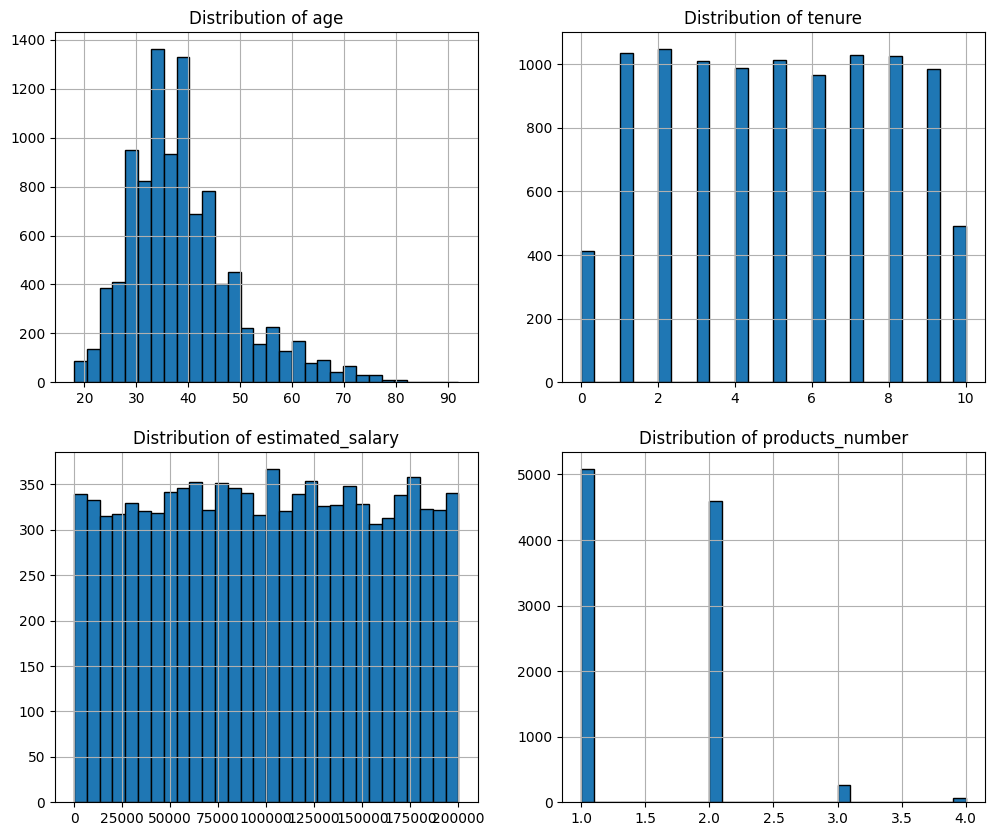

In [169]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cols = ['age', 'tenure', 'estimated_salary', 'products_number']
for ax, col in zip(axes.flatten(), cols):
    df[col].hist(ax=ax, bins=30, edgecolor='black')
    ax.set_title(f'Distribution of {col}')
# plt.tight_layout()
plt.show()

In [170]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: xlabel='credit_card', ylabel='count'>

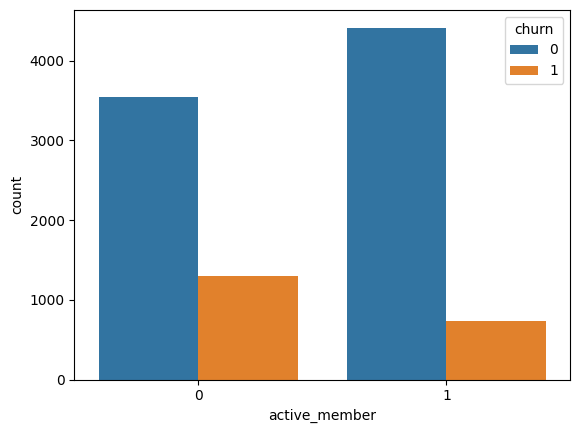

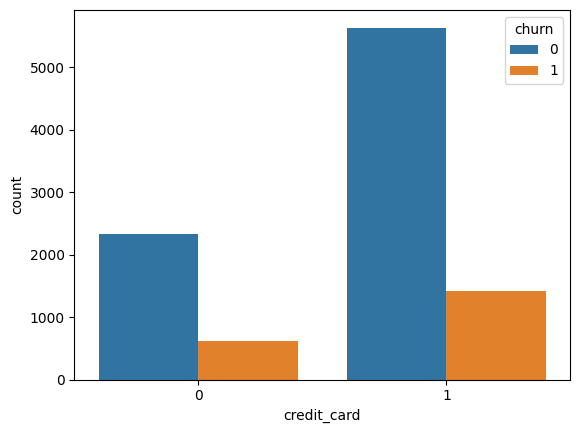

In [171]:

sns.countplot(data=df, x = 'active_member', hue='churn')


plt.figure()
sns.countplot(data=df, x = 'credit_card', hue='churn')

#checking churn vs active_member and credit_card


In [172]:
#checking unique values of tenure column 
df['tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

<Axes: xlabel='tenure', ylabel='count'>

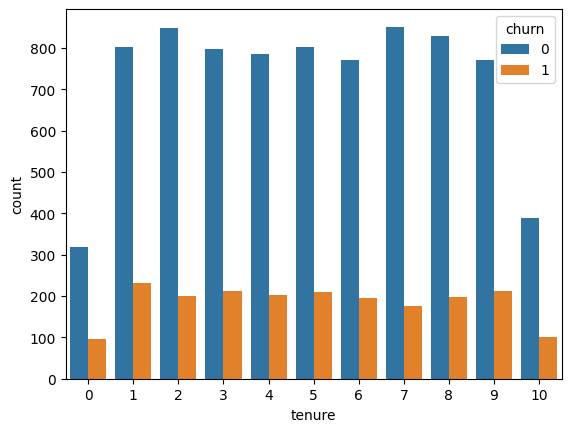

In [173]:
sns.countplot(data=df, x = 'tenure', hue='churn')


**COULDN'T Find ANY MeaningFul Insights**

In [174]:
#trying to rework the credit score column 
credit_score_column = df['credit_score']
print(credit_score_column.min())
print(credit_score_column.mean())
df['credit_score'].max()
# credit_score_column.unique()
df['temp'] = df['credit_score'] <500

# df.head(10)

# for index, i in enumerate(df['credit_score']<500):
# 	print(i)
	
# 	if(index ==10):
# 		break


df.head()
#just trying to figure out how to create column groups for credit_score




350
650.5288


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,temp
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,False
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,False
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,False
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,False
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,False


In [175]:
df = df.drop('temp', axis = 1)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [178]:
(850-350)/4

125.0

[0, 1, 2, 3]